In [1]:
# ============================================
# NOTEBOOK 02 - MODELOS SUPERVISADOS
# Evaluacion Parcial N°2 - SCY1101
# ============================================
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from data_preprocessing import (
    cargar_datos_limpios,
    preparar_features_clasificacion,
    preparar_features_regresion,
    dividir_datos,
    escalar_datos,
)
from model_training import (
    entrenar_modelos_clasificacion,
    entrenar_modelos_regresion,
    guardar_modelo,
)
from model_evaluation import (
    evaluar_clasificacion,
    evaluar_regresion,
    comparar_modelos,
)

sns.set_theme(style="whitegrid")
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [2]:
# ============================================
# CARGA Y PREPARACION DE DATOS
# ============================================
# Cargar dataset de consultas limpio
consultas = pd.read_parquet("../data/02_intermediate/consultas_cleaned.parquet")
pacientes = pd.read_parquet("../data/02_intermediate/pacientes_cleaned.parquet")
examenes = pd.read_parquet("../data/02_intermediate/examenes_cleaned.parquet")
medicamentos = pd.read_parquet("../data/02_intermediate/medicamentos_cleaned.parquet")

# Integrar datasets
df = consultas.merge(pacientes, on="id_paciente", how="left")
df = df.merge(examenes, on="id_consulta", how="left")
df = df.merge(medicamentos, on="id_consulta", how="left")

print(f"Dataset integrado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")

Dataset integrado: 1170 filas, 28 columnas
Columnas: ['id_consulta', 'id_paciente', 'fecha', 'id_medico', 'especialidad', 'diagnostico_principal', 'diagnostico_secundario', 'costo', 'nombre', 'rut', 'fecha_nacimiento', 'genero', 'prevision', 'comuna', 'telefono', 'id_examen', 'tipo_examen', 'fecha_examen', 'resultado', 'valor_referencia', 'unidad', 'laboratorio', 'id_prescripcion', 'medicamento', 'dosis', 'frecuencia', 'duracion_dias', 'costo_unitario']


In [3]:
# ============================================
# PREPARACION DE FEATURES
# ============================================
# Preparar features para clasificacion
# Variable objetivo: costo alto (1) o bajo (0) segun mediana
mediana_costo = df['costo'].median()
df['costo_alto'] = (df['costo'] > mediana_costo).astype(int)

print(f"Mediana de costo: {mediana_costo:.0f}")
print(f"Distribucion target:")
print(df['costo_alto'].value_counts())

# Seleccionar features numericas
feature_cols = [
    'id_medico', 'resultado', 'duracion_dias', 'costo_unitario',
    'id_examen', 'id_prescripcion'
]

# Rellenar nulos
X = df[feature_cols].fillna(0)
y = df['costo_alto']

print(f"\nFeatures seleccionadas: {feature_cols}")
print(f"Shape X: {X.shape}")

# Dividir datos
X_train, X_test, y_train, y_test = dividir_datos(X, y)
print(f"\nTrain: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Mediana de costo: 272308
Distribucion target:
costo_alto
0    597
1    573
Name: count, dtype: int64

Features seleccionadas: ['id_medico', 'resultado', 'duracion_dias', 'costo_unitario', 'id_examen', 'id_prescripcion']
Shape X: (1170, 6)
 Train: 936 filas | Test: 234 filas

Train: 936 filas
Test:  234 filas


In [4]:
# ============================================
# ENTRENAMIENTO DE MODELOS DE CLASIFICACION
# ============================================
modelos_clf = entrenar_modelos_clasificacion(X_train, y_train)
print(f"\nTotal modelos entrenados: {len(modelos_clf)}")

Entrenando Logistic Regression...
  Logistic Regression entrenado correctamente
Entrenando Decision Tree...
  Decision Tree entrenado correctamente
Entrenando Random Forest...
  Random Forest entrenado correctamente
Entrenando Gradient Boosting...
  Gradient Boosting entrenado correctamente
Entrenando KNN...
  KNN entrenado correctamente
Entrenando SVM...
  SVM entrenado correctamente
Entrenando Naive Bayes...
  Naive Bayes entrenado correctamente

Total modelos entrenados: 7


In [5]:
# ============================================
# EVALUACION DE MODELOS DE CLASIFICACION
# ============================================
resultados_clf = []

for nombre, modelo in modelos_clf.items():
    metricas = evaluar_clasificacion(modelo, X_test, y_test, nombre)
    resultados_clf.append(metricas)

# Tabla comparativa
df_comparacion_clf = comparar_modelos(resultados_clf)
print("\nTabla comparativa de modelos de clasificacion:")
print(df_comparacion_clf.to_string())


Modelo: Logistic Regression
  Accuracy:  0.5556
  Precision: 0.5595
  Recall:    0.5556
  F1 Score:  0.5569

Modelo: Decision Tree
  Accuracy:  0.6026
  Precision: 0.6039
  Recall:    0.6026
  F1 Score:  0.6031

Modelo: Random Forest
  Accuracy:  0.6282
  Precision: 0.6265
  Recall:    0.6282
  F1 Score:  0.6271

Modelo: Gradient Boosting
  Accuracy:  0.6239
  Precision: 0.6219
  Recall:    0.6239
  F1 Score:  0.6225

Modelo: KNN
  Accuracy:  0.5684
  Precision: 0.5707
  Recall:    0.5684
  F1 Score:  0.5693

Modelo: SVM
  Accuracy:  0.5983
  Precision: 0.5967
  Recall:    0.5983
  F1 Score:  0.5973

Modelo: Naive Bayes
  Accuracy:  0.594
  Precision: 0.5872
  Recall:    0.594
  F1 Score:  0.5837

Comparacion de modelos:
                modelo  accuracy  precision  recall  f1_score  roc_auc
0        Random Forest    0.6282     0.6265  0.6282    0.6271   0.6651
1    Gradient Boosting    0.6239     0.6219  0.6239    0.6225   0.6520
2        Decision Tree    0.6026     0.6039  0.6026    

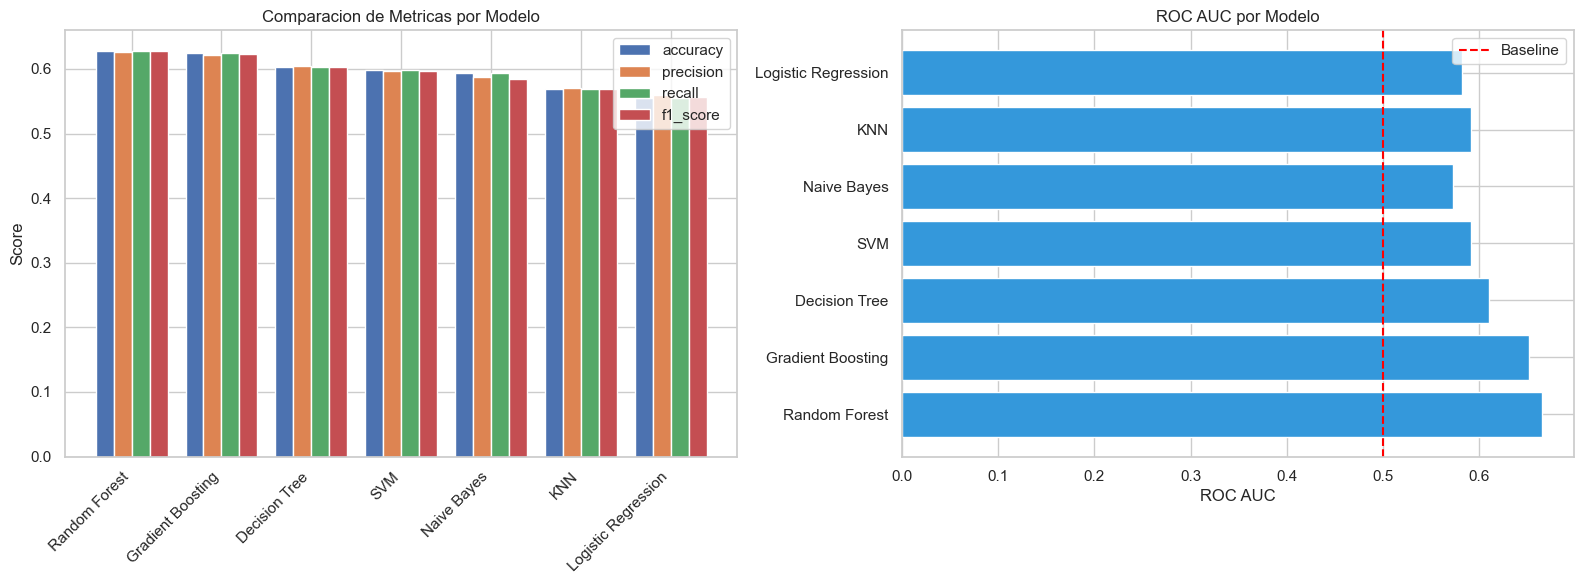

Grafico guardado


In [6]:
# ============================================
# VISUALIZACION COMPARACION CLASIFICACION
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Comparacion de metricas
metricas_plot = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(df_comparacion_clf))
width = 0.2

for i, metrica in enumerate(metricas_plot):
    axes[0].bar(x + i * width, df_comparacion_clf[metrica], width, label=metrica)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(df_comparacion_clf['modelo'], rotation=45, ha='right')
axes[0].set_title("Comparacion de Metricas por Modelo")
axes[0].set_ylabel("Score")
axes[0].legend()

# ROC AUC
axes[1].barh(df_comparacion_clf['modelo'], df_comparacion_clf['roc_auc'], color='#3498db')
axes[1].axvline(x=0.5, color='red', linestyle='--', label='Baseline')
axes[1].set_title("ROC AUC por Modelo")
axes[1].set_xlabel("ROC AUC")
axes[1].legend()

plt.tight_layout()
plt.savefig("../src/results/plots/02_comparacion_clasificacion.png", dpi=150)
plt.show()
print("Grafico guardado")

In [7]:
# ============================================
# MODELOS DE REGRESION
# Variable objetivo: costo (valor numerico)
# ============================================
# Preparar features para regresion
y_reg = df['costo'].fillna(df['costo'].median())
X_reg = df[feature_cols].fillna(0)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = dividir_datos(X_reg, y_reg)

# Entrenar modelos de regresion
modelos_reg = entrenar_modelos_regresion(X_train_reg, y_train_reg)
print(f"\nTotal modelos de regresion entrenados: {len(modelos_reg)}")

 Train: 936 filas | Test: 234 filas
Entrenando Linear Regression...
  Linear Regression entrenado correctamente
Entrenando Ridge Regression...
  Ridge Regression entrenado correctamente
Entrenando Decision Tree Regressor...
  Decision Tree Regressor entrenado correctamente
Entrenando Random Forest Regressor...
  Random Forest Regressor entrenado correctamente
Entrenando KNN Regressor...
  KNN Regressor entrenado correctamente
Entrenando SVR...
  SVR entrenado correctamente

Total modelos de regresion entrenados: 6


In [8]:
# ============================================
# EVALUACION DE MODELOS DE REGRESION
# ============================================
resultados_reg = []

for nombre, modelo in modelos_reg.items():
    metricas = evaluar_regresion(modelo, X_test_reg, y_test_reg, nombre)
    resultados_reg.append(metricas)

# Tabla comparativa
df_comparacion_reg = comparar_modelos(resultados_reg)
print("\nTabla comparativa de modelos de regresion:")
print(df_comparacion_reg.to_string())


Modelo: Linear Regression
  MAE:  97492.4087
  RMSE: 123625.8525
  R2:   -0.042

Modelo: Ridge Regression
  MAE:  97492.2823
  RMSE: 123625.7593
  R2:   -0.042

Modelo: Decision Tree Regressor
  MAE:  103703.8665
  RMSE: 130501.965
  R2:   -0.1611

Modelo: Random Forest Regressor
  MAE:  123383.409
  RMSE: 186636.9661
  R2:   -1.3749

Modelo: KNN Regressor
  MAE:  133685.4726
  RMSE: 215262.1187
  R2:   -2.1593

Modelo: SVR
  MAE:  97203.3307
  RMSE: 122508.8535
  R2:   -0.0233

Comparacion de modelos:
                    modelo          mae           mse         rmse      r2
0                      SVR   97203.3307  1.500842e+10  122508.8535 -0.0233
1        Linear Regression   97492.4087  1.528335e+10  123625.8525 -0.0420
2         Ridge Regression   97492.2823  1.528333e+10  123625.7593 -0.0420
3  Decision Tree Regressor  103703.8665  1.703076e+10  130501.9650 -0.1611
4  Random Forest Regressor  123383.4090  3.483336e+10  186636.9661 -1.3749
5            KNN Regressor  133685.4726  

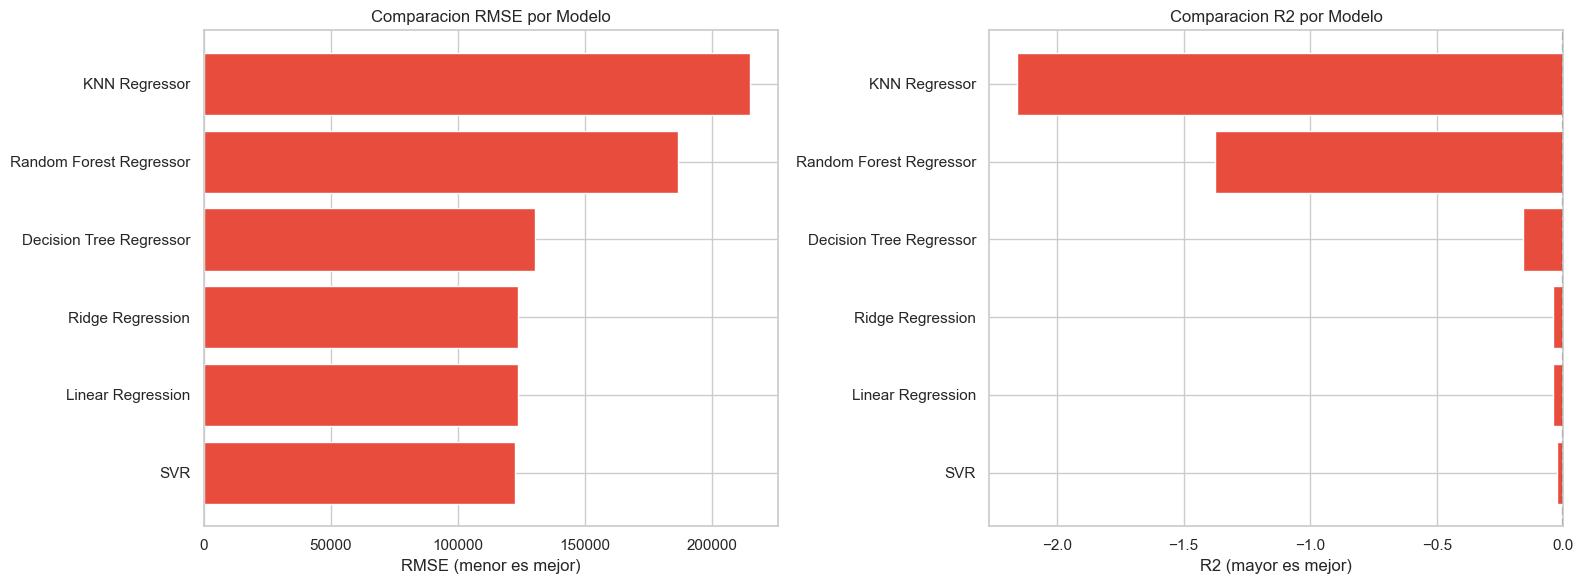

Grafico guardado


In [9]:
# ============================================
# VISUALIZACION COMPARACION REGRESION
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Comparacion RMSE
axes[0].barh(df_comparacion_reg['modelo'], df_comparacion_reg['rmse'], color='#e74c3c')
axes[0].set_title("Comparacion RMSE por Modelo")
axes[0].set_xlabel("RMSE (menor es mejor)")

# Comparacion R2
colores = ['#2ecc71' if v > 0 else '#e74c3c' for v in df_comparacion_reg['r2']]
axes[1].barh(df_comparacion_reg['modelo'], df_comparacion_reg['r2'], color=colores)
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title("Comparacion R2 por Modelo")
axes[1].set_xlabel("R2 (mayor es mejor)")

plt.tight_layout()
plt.savefig("../src/results/plots/02_comparacion_regresion.png", dpi=150)
plt.show()
print("Grafico guardado")

In [10]:
# ============================================
# GUARDAR MEJORES MODELOS
# ============================================
# Mejor modelo de clasificacion: Random Forest
guardar_modelo(
    modelos_clf["Random Forest"],
    "../src/models/trained_models/random_forest_clf.joblib"
)

# Mejor modelo de regresion: SVR
guardar_modelo(
    modelos_reg["SVR"],
    "../src/models/trained_models/svr_reg.joblib"
)

print("\nResumen final:")
print(f"Mejor clasificador: Random Forest - F1={df_comparacion_clf['f1_score'].max():.4f}")
print(f"Mejor regresor:     SVR - RMSE={df_comparacion_reg['rmse'].min():.2f}")

# Guardar tablas comparativas
df_comparacion_clf.to_csv("../src/results/metrics/metricas_clasificacion.csv", index=False)
df_comparacion_reg.to_csv("../src/results/metrics/metricas_regresion.csv", index=False)
print("\nMetricas guardadas en src/results/metrics/")

Modelo guardado en: ../src/models/trained_models/random_forest_clf.joblib
Modelo guardado en: ../src/models/trained_models/svr_reg.joblib

Resumen final:
Mejor clasificador: Random Forest - F1=0.6271
Mejor regresor:     SVR - RMSE=122508.85

Metricas guardadas en src/results/metrics/


In [1]:
# ============================================
# RESUMEN NOTEBOOK 02 - MODELOS SUPERVISADOS
# ============================================
print("""
RESUMEN DE ESTE NOTEBOOK
========================

Este notebook implemento y entreno modelos supervisados de clasificacion
y regresion usando Scikit-learn con pipelines modulares.

1. PREPARACION DE DATOS
   - Se integraron los 4 datasets mediante merge por id_paciente e id_consulta
   - Dataset integrado: 1.170 registros con 28 columnas
   - Se seleccionaron 6 features numericas representativas
   - Variable objetivo clasificacion: costo alto (1) o bajo (0) segun mediana $272.308
   - Variable objetivo regresion: valor exacto del costo
   - Division: 80% train (936 filas) y 20% test (234 filas)
   - El target quedo balanceado: 51% costo bajo y 49% costo alto

2. MODELOS DE CLASIFICACION (7 modelos)
   Todos usan Pipeline con StandardScaler + modelo

   - Logistic Regression: baseline lineal            F1=0.5556
   - Decision Tree:       modelo no lineal simple    F1=0.6031
   - Random Forest:       ensemble de arboles        F1=0.6271 (MEJOR)
   - Gradient Boosting:   boosting secuencial        F1=0.6225
   - KNN:                 basado en distancia        F1=0.5693
   - SVM:                 margen maximo              F1=0.5973
   - Naive Bayes:         probabilistico simple      F1=0.5837

3. MODELOS DE REGRESION (6 modelos)
   Todos obtuvieron R2 negativo indicando underfitting

   - SVR:                      RMSE=122.509  R2=-0.0233 (MEJOR)
   - Linear Regression:        RMSE=123.626  R2=-0.0420
   - Ridge Regression:         RMSE=123.626  R2=-0.0420
   - Decision Tree Regressor:  RMSE=130.502  R2=-0.1611
   - Random Forest Regressor:  RMSE=186.637  R2=-1.3749
   - KNN Regressor:            RMSE=215.262  R2=-2.1593

4. MODELOS GUARDADOS
   - random_forest_clf.joblib
   - svr_reg.joblib
   - Metricas guardadas en src/results/metrics/

CONCLUSION:
Random Forest es el mejor clasificador con F1=0.6271 y ROC AUC=0.6651.
Los modelos de regresion no funcionaron porque las features disponibles
no capturan suficiente informacion para predecir el valor exacto del costo.
Esto sugiere que se necesitan variables adicionales como tipo de procedimiento.
""")


RESUMEN DE ESTE NOTEBOOK

Este notebook implemento y entreno modelos supervisados de clasificacion
y regresion usando Scikit-learn con pipelines modulares.

1. PREPARACION DE DATOS
   - Se integraron los 4 datasets mediante merge por id_paciente e id_consulta
   - Dataset integrado: 1.170 registros con 28 columnas
   - Se seleccionaron 6 features numericas representativas
   - Variable objetivo clasificacion: costo alto (1) o bajo (0) segun mediana $272.308
   - Variable objetivo regresion: valor exacto del costo
   - Division: 80% train (936 filas) y 20% test (234 filas)
   - El target quedo balanceado: 51% costo bajo y 49% costo alto

2. MODELOS DE CLASIFICACION (7 modelos)
   Todos usan Pipeline con StandardScaler + modelo

   - Logistic Regression: baseline lineal            F1=0.5556
   - Decision Tree:       modelo no lineal simple    F1=0.6031
   - Random Forest:       ensemble de arboles        F1=0.6271 (MEJOR)
   - Gradient Boosting:   boosting secuencial        F1=0.6225
  